In [3]:
import pandas as pd
from sklearn.datasets import fetch_california_housing

# Fetch California housing dataset directly into a Pandas DataFrame
housing = fetch_california_housing(as_frame=True)
df = housing.frame

# Inspect the data
display(df.head())
df.info()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


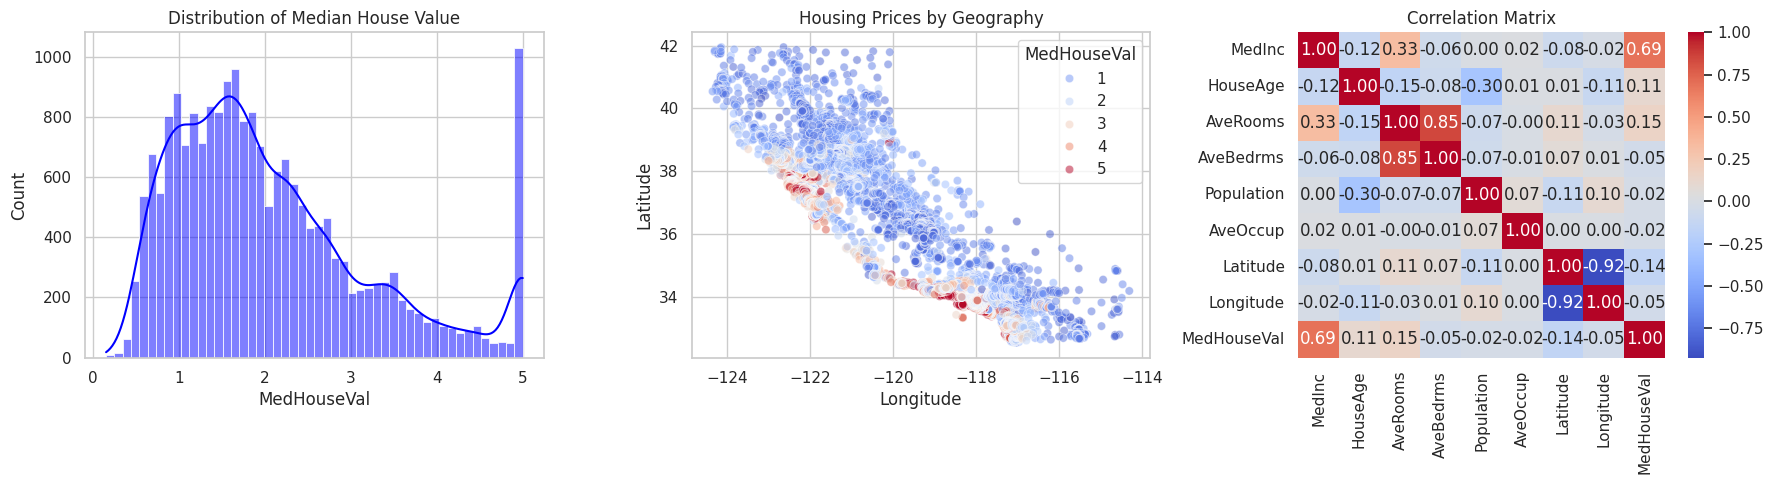

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['MedHouseVal'], bins=50, ax=axes[0], color='blue', kde=True)
axes[0].set_title('Distribution of Median House Value')
axes[0].set_xlabel('MedHouseVal')
axes[0].set_ylabel('Count')

sns.scatterplot(
    x='Longitude',
    y='Latitude',
    hue='MedHouseVal',
    data=df,
    palette='coolwarm',
    alpha=0.5,
    ax=axes[1]
)
axes[1].set_title('Housing Prices by Geography')

# 3. Correlation Heatmap
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[2], cbar=True)
axes[2].set_title('Correlation Matrix')

plt.tight_layout()

plt.savefig('fig1.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('fig2.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('fig3.png', dpi=300, bbox_inches='tight', facecolor='white')

plt.show()

In [14]:
plt.savefig('fig1.png')
plt.savefig('fig2.png')
plt.savefig('fig3.png')
plt.show()

<Figure size 640x480 with 0 Axes>

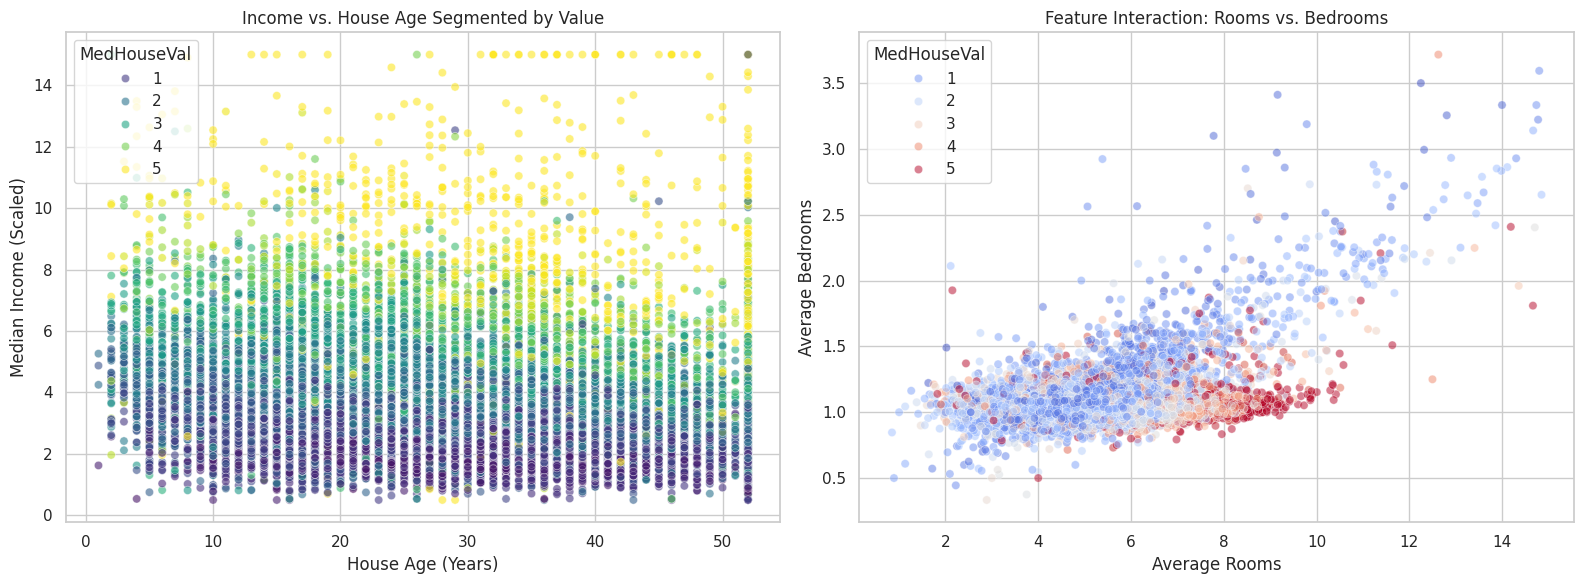

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing(as_frame=True)
df= housing.frame
fig, axes = plt.subplots(1,2, figsize =(16,6))
sns.scatterplot(
    data=df,
    x="HouseAge",
    y='MedInc',
    hue='MedHouseVal',
    palette='viridis',
    alpha=0.6,
    ax=axes[0]

)
axes[0].set_title('Income vs. House Age Segmented by Value')
axes[0].set_xlabel('House Age (Years)')
axes[0].set_ylabel('Median Income (Scaled)')

df_filtered = df[(df['AveRooms'] < 15) &(df['AveBedrms'] <5)]
sns.scatterplot(
    data=df_filtered,
    x="AveRooms",
    y="AveBedrms",
    hue="MedHouseVal",
    palette="coolwarm",
    alpha = 0.5,
    ax= axes[1]
)
axes[1].set_title('Feature Interaction: Rooms vs. Bedrooms')
axes[1].set_xlabel('Average Rooms')
axes[1].set_ylabel('Average Bedrooms')
plt.tight_layout()

plt.savefig('fig4_age_income.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('fig5_rooms.png', dpi=300, bbox_inches='tight', facecolor='white')

plt.show()

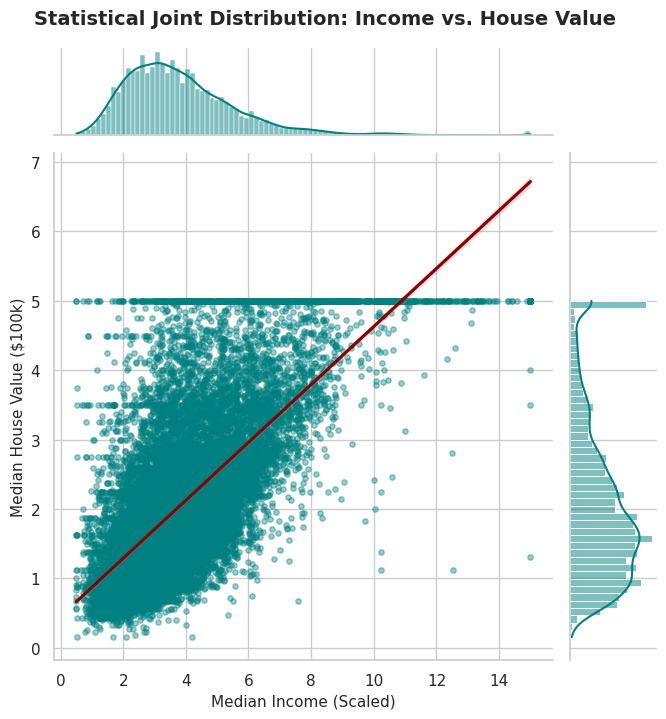

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
g= sns.jointplot(
    x="MedInc",
    y="MedHouseVal",
    data=df,
    kind="reg",
    color="teal",
    height=7,
    scatter_kws={'alpha': 0.4, 's': 15},
    line_kws={'color': 'darkred'}
)
g.fig.suptitle('Statistical Joint Distribution: Income vs. House Value', y=1.03, fontsize=14, fontweight='bold')
g.set_axis_labels('Median Income (Scaled)', 'Median House Value ($100k)', fontsize=11)

plt.savefig('fig6_joint_income_value.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

/tmp/ipykernel_1703/3515041340.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


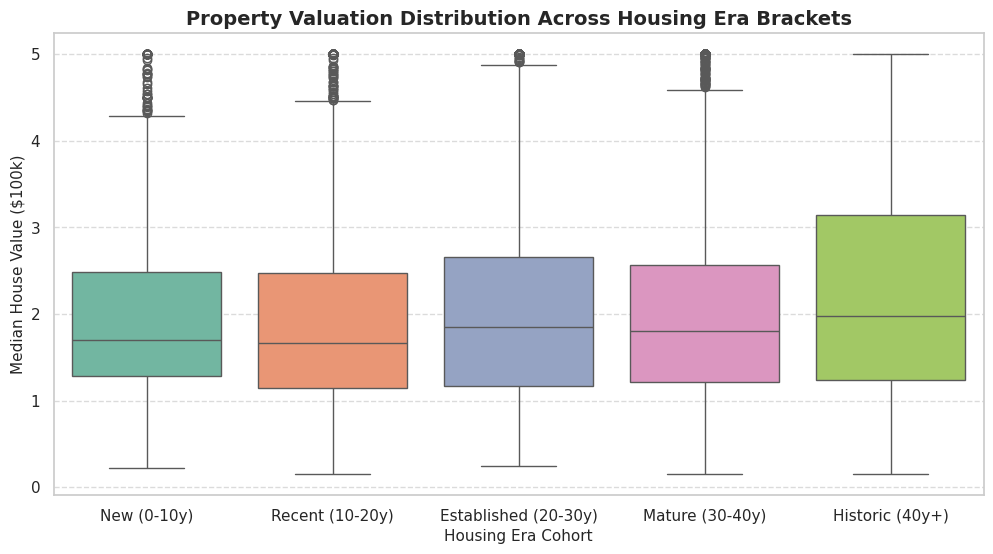

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df['Age_Category'] = pd.cut(
    df['HouseAge'],
    bins=[0, 10, 20, 30, 40, 52],
    labels=['New (0-10y)', 'Recent (10-20y)', 'Established (20-30y)', 'Mature (30-40y)', 'Historic (40y+)']
)

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df,
    x='Age_Category',
    y='MedHouseVal',
    palette='Set2'
)
plt.title('Property Valuation Distribution Across Housing Era Brackets', fontsize=14, fontweight='bold')
plt.xlabel('Housing Era Cohort', fontsize=11)
plt.ylabel('Median House Value ($100k)', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.savefig('fig7_era_boxplots.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


In [7]:

stats_table = df.describe().T[['count', 'mean', 'std', 'min', '50%', 'max']]
stats_table.columns = ['Count', 'Mean', 'Standard Deviation', 'Min', 'Median (50%)', 'Max']
display(stats_table)

,Count,Mean,Standard Deviation,Min,Median (50%),Max
MedInc,20640.0,3.870671,1.899822,0.499900,3.534800,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,29.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,5.229129,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.048780,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,1166.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.818116,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,34.260000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-118.490000,-114.310000
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.797000,5.000010
